# TCC MBA — EDA: Detecção de Fraudes
**FIA Business School | LABDATA | Banco FIA MBA Digital**

Execute as células em ordem com **Shift+Enter**. A Célula 17 pode ser rodada isoladamente após o merge.

| Bloco | Células | Conteúdo |
|-------|---------|----------|
| BLOCO 1 | 1–4 | Estrutura do Dataset |
| BLOCO 2 | 5 | Target & Desbalanceamento |
| BLOCO 3 | 6 | Qualidade dos Dados |
| BLOCO 4 | 7–11 | Variáveis-Chave |
| BLOCO 5 | 12–16 | Correlações com Fraude |
| RESUMO | 17 | Síntese Executiva |

## BLOCO 1 — Estrutura do Dataset

In [1]:
# CÉLULA 1 — Instalações e Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import os
import json
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = ['#2EC4B6', '#E71D36', '#FF9F1C', '#4361EE', '#7209B7']

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [2]:
import json
from pathlib import Path

path = Path("..") / "vars.json"


with path.open("r", encoding="utf-8") as f:
    var_json = json.load(f)

print(var_json)

{'caminho_treino_transcation': 'train_transaction.csv', 'caminho_treino_identity': 'train_identity.csv'}


In [3]:
PATH_TRAIN_TRANSACTIONS = Path("..") / "Dados" / var_json["caminho_treino_transcation"]
PATH_TRAIN_IDENTITY = Path("..") / "Dados" / var_json["caminho_treino_identity"]

In [4]:
PATH_TRAIN_TRANSACTIONS

WindowsPath('../Dados/train_transaction.csv')

In [5]:
# CÉLULA 2 — Carregamento dos Dados
# POR QUÊ dois arquivos: transações e identidade são tabelas separadas na
# Vesta — nem toda transação tem dados de identidade disponíveis.

# IMPORTANTE: descomente APENAS UMA das opções abaixo antes de executar.

# ── OPÇÃO A: Upload manual (simples; arquivos somem ao fechar a sessão) ────
# from google.colab import files
# uploaded = files.upload()   # selecione train_transaction.csv e train_identity.csv
# DATA_PATH = ''


# ── OPÇÃO C: Execução local, fora do Colab ─────────────────────────────────
# DATA_PATH = 'Dados/raw/'

print('Carregando dados de transacoes...')
df_trans = pd.read_csv(PATH_TRAIN_TRANSACTIONS)

print('Carregando dados de identidade...')
df_ident = pd.read_csv(PATH_TRAIN_IDENTITY)

print(f'train_transaction : {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas')
print(f'train_identity    : {df_ident.shape[0]:,} linhas | {df_ident.shape[1]} colunas')

Carregando dados de transacoes...
Carregando dados de identidade...
train_transaction : 590,540 linhas | 394 colunas
train_identity    : 144,233 linhas | 41 colunas


In [6]:
# CÉLULA 3 — Merge das Tabelas
# LEFT JOIN: mantém todas as 590 mil transações; as sem identidade ficam NaN.
df = df_trans.merge(df_ident, on='TransactionID', how='left')

n_com_identity = df_ident['TransactionID'].nunique()
print(f'Dataset consolidado : {df.shape[0]:,} linhas | {df.shape[1]} colunas')
print(f'Com dados de identidade: {n_com_identity:,} ({n_com_identity/len(df)*100:.1f}%)')
print(f'Sem dados de identidade: {len(df)-n_com_identity:,} ({(len(df)-n_com_identity)/len(df)*100:.1f}%)')
print()
print('>> INSIGHT: 3 em cada 4 transacoes NAO tem dados de dispositivo/browser.')
print('   Isso sera importante na etapa de preparacao — ausencia pode ser sinal de risco.')

## Por que isso é um "insight" e não apenas um dado faltante?
## Em fraude de cartão card-not-present (CNP), o dado de dispositivo é coletado ativamente pelo gateway no momento da transação — é ele que registra qual browser, qual sistema operacional, qual fingerprint de máquina.
## Se esse dado não existe, há três possibilidades:
## 1. Transação legítima via canal sem coleta (ex: compra por telefone, batch payment) — o sistema simplesmente não coleta device nesses canais
## 2. Transação onde o cliente não passou pelo checkout normal — pode indicar automação ou bypass
## 3. Limitação da integração da loja — nem todos os parceiros do gateway enviam esses campos
## O contra-intuitivo que o EDA mostra é que transações sem dado de device têm taxa de fraude de 2,1%, enquanto as com device têm taxas maiores (desktop 6,5%, mobile 10,2%). Isso sugere que a Vesta só coletava device quando já havia algum sinal de alerta — ou seja, a presença do dado é que é suspeita, não a ausência.

Dataset consolidado : 590,540 linhas | 434 colunas
Com dados de identidade: 144,233 (24.4%)
Sem dados de identidade: 446,307 (75.6%)

>> INSIGHT: 3 em cada 4 transacoes NAO tem dados de dispositivo/browser.
   Isso sera importante na etapa de preparacao — ausencia pode ser sinal de risco.


In [7]:
# CÉLULA 4 — Mapa de Grupos de Variáveis
# Cada grupo recebe tratamento diferente de nulos e tem relevância preditiva distinta.

# c[0]=='C' and c[1:].isdigit() seleciona colunas como C1, C2, ..., C14
col_groups = {
    'Target'         : ['isFraud'],
    'Transacao base' : ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Cartao'         : [c for c in df.columns if c.startswith('card')],
    'Endereco/Dist'  : [c for c in df.columns if c.startswith('addr') or c.startswith('dist')],
    'E-mail'         : ['P_emaildomain', 'R_emaildomain'],
    'Contagem (C)'   : [c for c in df.columns if c[0]=='C' and c[1:].isdigit()],
    'Temporal (D)'   : [c for c in df.columns if c[0]=='D' and c[1:].isdigit()],
    'Match (M)'      : [c for c in df.columns if c[0]=='M' and c[1:].isdigit()],
    'Vesta (V)'      : [c for c in df.columns if c[0]=='V' and c[1:].isdigit()],
    'Identidade (id)': [c for c in df.columns if c.startswith('id_')],
    'Dispositivo'    : ['DeviceType', 'DeviceInfo'],
}

print('Grupo              Variaveis   % do total')
print('-' * 42)
total = 0
for grupo, colunas in col_groups.items():
    exist = [c for c in colunas if c in df.columns]
    total += len(exist)
    pct = len(exist) / df.shape[1] * 100
    print(f'  {grupo:<16} {len(exist):>10}  {pct:>9.1f}%')
print('-' * 42)
print(f'  TOTAL            {total:>10}')
print()
print(f'Tipos de dados: {dict(df.dtypes.value_counts())}')

Grupo              Variaveis   % do total
------------------------------------------
  Target                    1        0.2%
  Transacao base            3        0.7%
  Cartao                    6        1.4%
  Endereco/Dist             4        0.9%
  E-mail                    2        0.5%
  Contagem (C)             14        3.2%
  Temporal (D)             15        3.5%
  Match (M)                 9        2.1%
  Vesta (V)               339       78.1%
  Identidade (id)          38        8.8%
  Dispositivo               2        0.5%
------------------------------------------
  TOTAL                   433

Tipos de dados: {dtype('float64'): np.int64(399), <StringDtype(na_value=nan)>: np.int64(31), dtype('int64'): np.int64(4)}


## BLOCO 2 — Target & Desbalanceamento

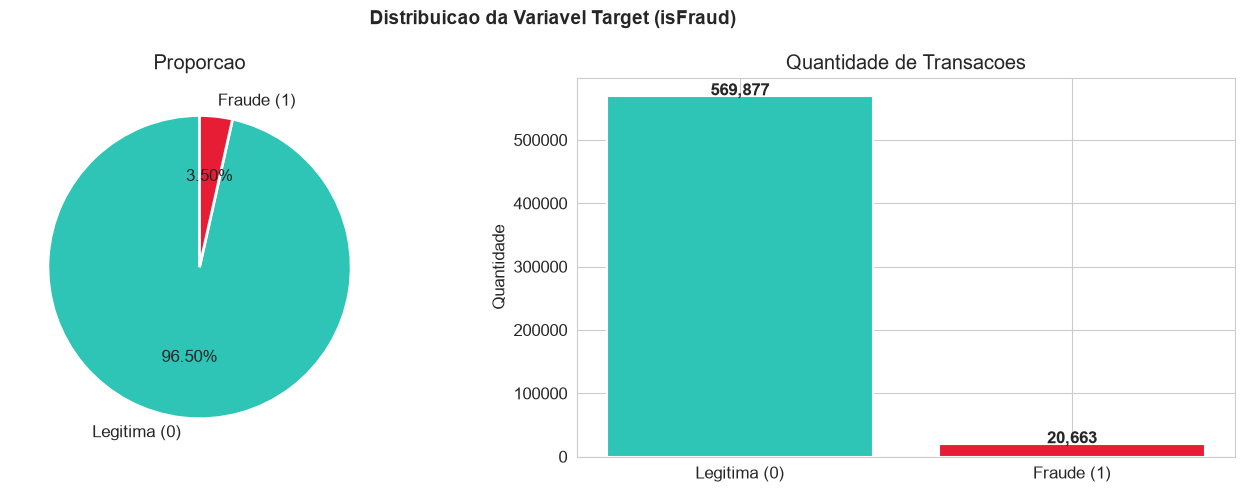

Taxa de fraude          : 3.50%
Transacoes legitimas    : 569,877
Transacoes fraudulentas : 20,663
Razao                   : 1 fraude para cada 27 legitimas

>> INSIGHT: Dataset fortemente desbalanceado.
   Na modelagem: usar class_weight='balanced' ou SMOTE.
   Na avaliacao: usar AUC-ROC e Recall, NUNCA so acuracia.


In [8]:
# CÉLULA 5 — Distribuição do Target (isFraud)
# Um modelo que chute 'tudo legítimo' acerta 96,5% — por isso acurácia é
# enganosa e usamos AUC-ROC.
fraude_counts = df['isFraud'].value_counts().sort_index()
fraud_rate = df['isFraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuicao da Variavel Target (isFraud)', fontsize=14, fontweight='bold')

labels = ['Legitima (0)', 'Fraude (1)']
colors = [PALETTE[0], PALETTE[1]]

axes[0].pie(fraude_counts, labels=labels, colors=colors, autopct='%1.2f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporcao')

bars = axes[1].bar(labels, fraude_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Quantidade de Transacoes')
axes[1].set_ylabel('Quantidade')
for bar, val in zip(bars, fraude_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Taxa de fraude          : {fraud_rate:.2f}%')
print(f'Transacoes legitimas    : {fraude_counts[0]:,}')
print(f'Transacoes fraudulentas : {fraude_counts[1]:,}')
print(f'Razao                   : 1 fraude para cada {fraude_counts[0]//fraude_counts[1]:.0f} legitimas')
print()
print('>> INSIGHT: Dataset fortemente desbalanceado.')
print("   Na modelagem: usar class_weight='balanced' ou SMOTE.")
print('   Na avaliacao: usar AUC-ROC e Recall, NUNCA so acuracia.')

## BLOCO 3 — Qualidade dos Dados

Colunas sem nulos          : 52
Nulos <  30%  (imputar)    : 150
Nulos 30-70%  (avaliar)    : 24
Nulos >  70%  (excluir?)   : 208


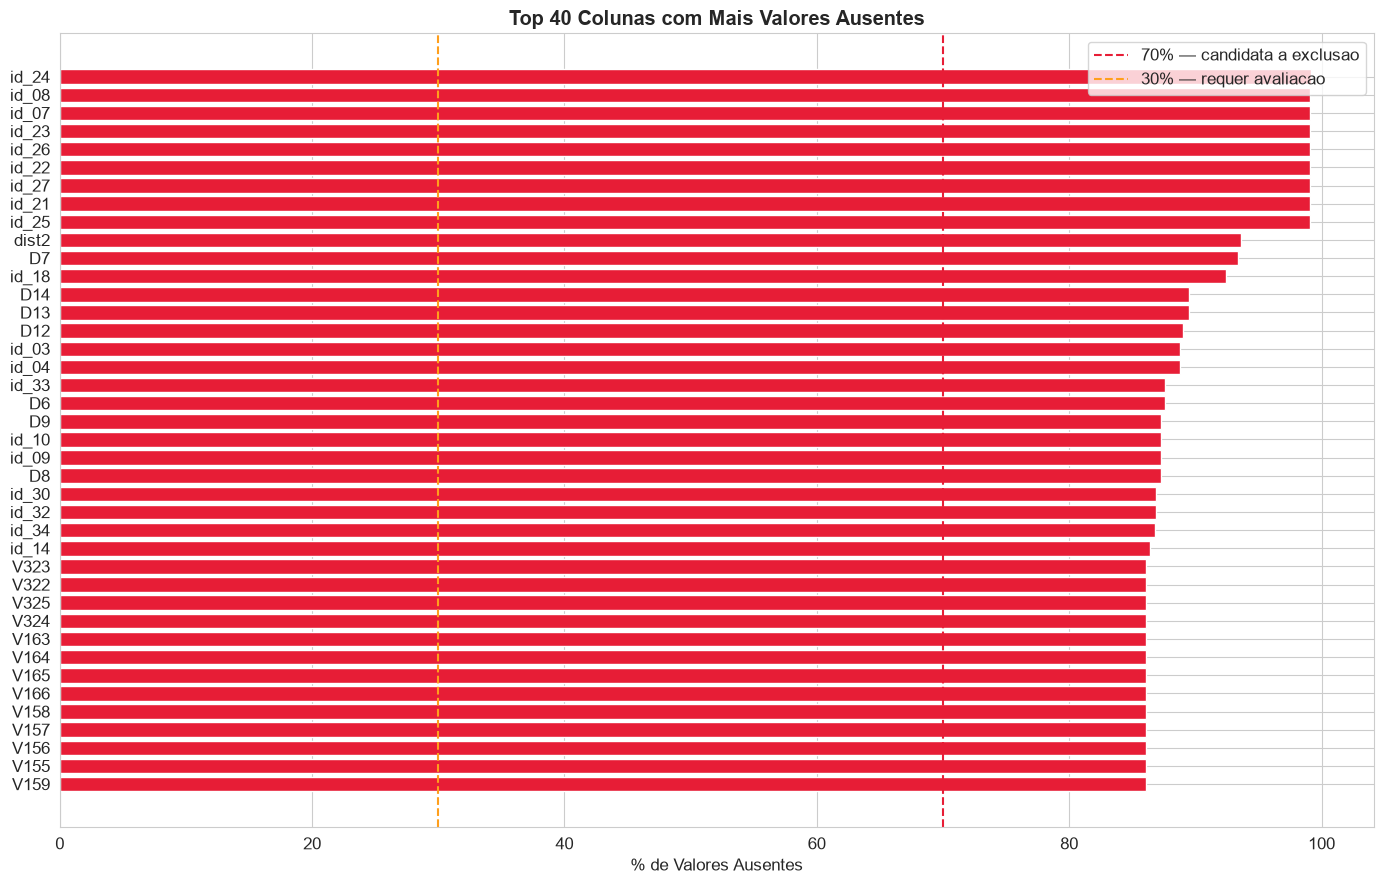


Missingness media por grupo de variaveis:
  Target            : media   0.0% | pior   0.0%
  Transacao base    : media   0.0% | pior   0.0%
  Cartao            : media   0.5% | pior   1.5%
  Endereco/Dist     : media  43.9% | pior  93.6%
  E-mail            : media  46.4% | pior  76.8%
  Contagem (C)      : media   0.0% | pior   0.0%
  Temporal (D)      : media  58.2% | pior  93.4%
  Match (M)         : media  49.9% | pior  59.3%
  Vesta (V)         : media  43.0% | pior  86.1%
  Identidade (id)   : media  84.8% | pior  99.2%
  Dispositivo       : media  78.0% | pior  79.9%

>> INSIGHT: Nulos estruturais (nao erros) — criar flag '_missing' antes de imputar.


In [9]:
# CÉLULA 6 — Análise de Valores Ausentes
# Nulos em fraude NÃO são aleatórios — ausência de um campo pode significar
# que a verificação falhou, o que é um sinal de risco em si mesmo.
miss_pct = (df.isnull().mean() * 100).round(1)
miss_df  = miss_pct[miss_pct > 0].sort_values(ascending=False)

alta  = miss_df[miss_df > 70]
media = miss_df[(miss_df > 30) & (miss_df <= 70)]
baixa = miss_df[miss_df <= 30]

print(f'Colunas sem nulos          : {(miss_pct == 0).sum()}')
print(f'Nulos <  30%  (imputar)    : {len(baixa)}')
print(f'Nulos 30-70%  (avaliar)    : {len(media)}')
print(f'Nulos >  70%  (excluir?)   : {len(alta)}')

top40 = miss_df.head(40)
# cor por faixa: vermelho >70%, laranja 30-70%, verde <30%
bar_colors = ['#E71D36' if p > 70 else '#FF9F1C' if p > 30 else '#2EC4B6' for p in top40.values]

fig, ax = plt.subplots(figsize=(14, 9))
ax.barh(top40.index[::-1], top40.values[::-1], color=bar_colors[::-1])  # [::-1] inverte para maior ficar no topo
ax.axvline(70, color='#E71D36', linestyle='--', linewidth=1.5, label='70% — candidata a exclusao')
ax.axvline(30, color='#FF9F1C', linestyle='--', linewidth=1.5, label='30% — requer avaliacao')
ax.set_xlabel('% de Valores Ausentes')
ax.set_title('Top 40 Colunas com Mais Valores Ausentes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print()
print('Missingness media por grupo de variaveis:')
for grupo, colunas in col_groups.items():
    exist = [c for c in colunas if c in df.columns]
    if not exist:
        continue
    med  = df[exist].isnull().mean().mean() * 100
    pior = df[exist].isnull().mean().max() * 100
    print(f'  {grupo:<18}: media {med:5.1f}% | pior {pior:5.1f}%')

print()
print(">> INSIGHT: Nulos estruturais (nao erros) — criar flag '_missing' antes de imputar.")

## BLOCO 4 — Variáveis-Chave

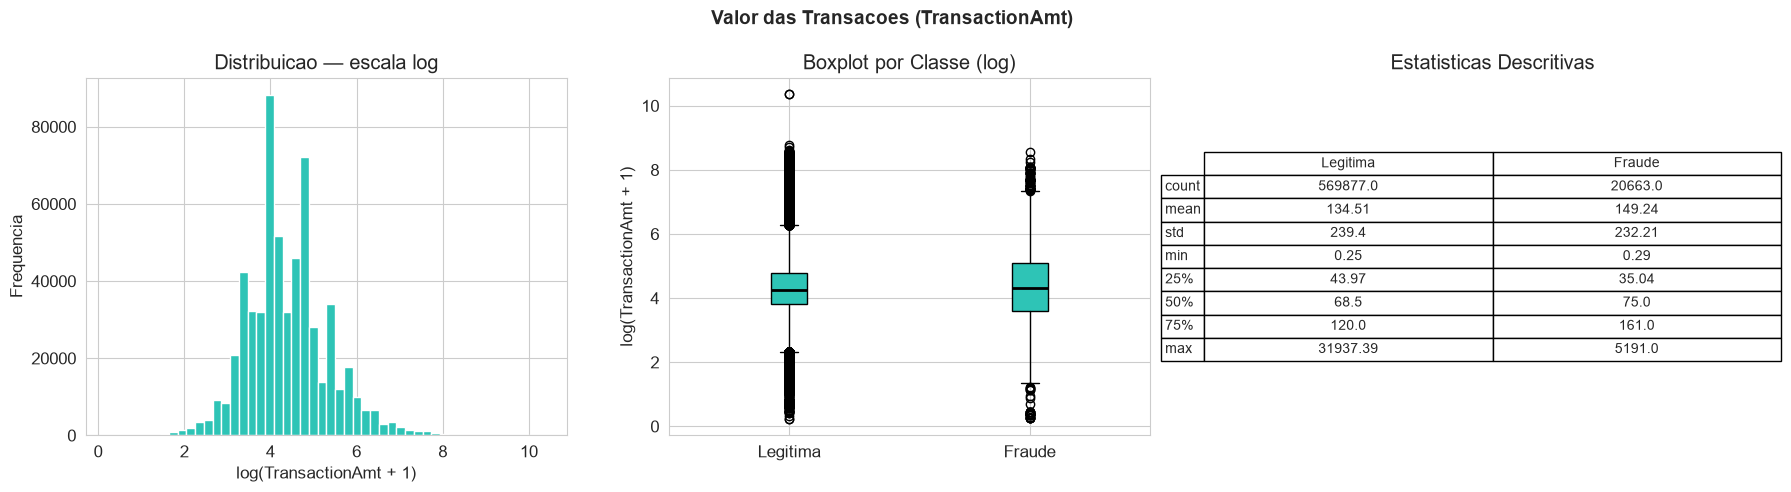

Skewness (assimetria): 14.4
>> INSIGHT: Skewness de 14 indica cauda longa a direita.
   Aplicar log1p(TransactionAmt) na Etapa 3 antes de modelar.
   Mediana fraude USD 75 vs legit USD 68 — diferenca pequena.


In [17]:
# CÉLULA 7 — Valor da Transação (TransactionAmt)
# Distribuição muito assimétrica (cauda longa) — aplicar log antes do modelo
# para não deixar valores extremos dominarem o aprendizado.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Valor das Transacoes (TransactionAmt)', fontsize=14, fontweight='bold')
# log1p(x) = log(1 + x) — evita log(0)
axes[0].hist(np.log1p(df['TransactionAmt']), bins=50, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao — escala log')
legit  = np.log1p(df[df['isFraud']==0]['TransactionAmt'])
fraude = np.log1p(df[df['isFraud']==1]['TransactionAmt'])
axes[1].boxplot([legit, fraude], tick_labels=['Legitima', 'Fraude'], patch_artist=True,
                 boxprops=dict(facecolor=PALETTE[0]),
                 medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('log(TransactionAmt + 1)')
axes[1].set_title('Boxplot por Classe (log)')
# tabela de estatísticas dentro do gráfico
stats = df.groupby('isFraud')['TransactionAmt'].describe().T
stats.columns = ['Legitima', 'Fraude']
axes[2].axis('off')  # esconde os eixos para mostrar só a tabela
tbl = axes[2].table(cellText=stats.round(2).values,
rowLabels=stats.index, colLabels=stats.columns,
cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
axes[2].set_title('Estatisticas Descritivas')
plt.tight_layout()
plt.show()
skewness = df['TransactionAmt'].skew()
med_f = df[df['isFraud']==1]['TransactionAmt'].median()
med_l = df[df['isFraud']==0]['TransactionAmt'].median()
print(f'Skewness (assimetria): {skewness:.1f}')
print('>> INSIGHT: Skewness de 14 indica cauda longa a direita.')
print('   Aplicar log1p(TransactionAmt) na Etapa 3 antes de modelar.')
print(f'   Mediana fraude USD {med_f:.0f} vs legit USD {med_l:.0f} — diferenca pequena.')

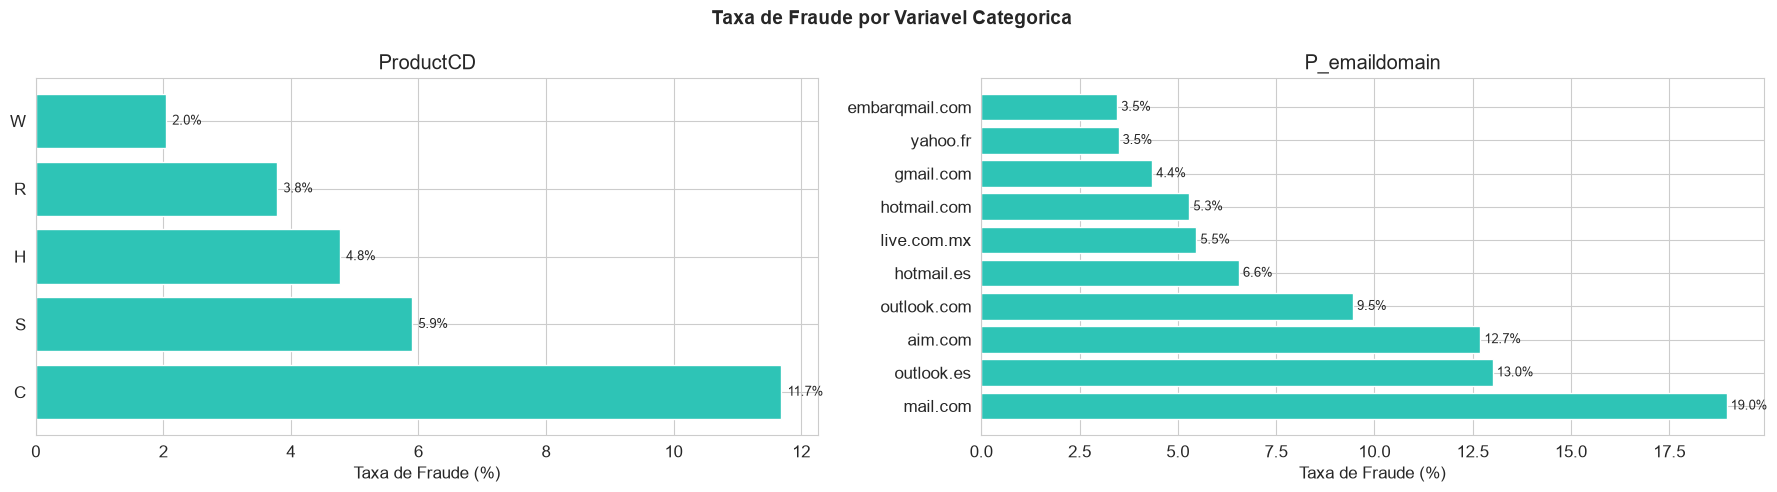

ProductCD — detalhe:
            total  share_%  fraudes  taxa_%  valor_medio
ProductCD                                               
C           68519     11.6     8008    11.7         42.9
S           11628      2.0      686     5.9         60.3
H           33024      5.6     1574     4.8         73.2
R           37699      6.4     1426     3.8        168.3
W          439670     74.5     8969     2.0        153.2

>> INSIGHT: Produto C (cashout) tem 11.7% de fraude — quase 6x a taxa do produto W.
   Ticket medio de cashout e menor (USD 43), mas fraude e concentrada.


In [18]:
# CÉLULA 8 — ProductCD e E-mail: Taxa de Fraude por Categoria
# card4, card6 e DeviceType têm análise própria nas Células 9 e 11.
cat_cols = ['ProductCD', 'P_emaildomain']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
fig.suptitle('Taxa de Fraude por Variavel Categorica', fontsize=14, fontweight='bold')

for ax, col in zip(axes, cat_cols):
    stats = df.groupby(col, dropna=False)['isFraud'].agg(['mean', 'count']).reset_index()
    stats[col] = stats[col].fillna('(sem dado)').astype(str)
    stats = stats[stats['count'] >= 100].sort_values('mean', ascending=False).head(10)
    barras = ax.barh(stats[col], stats['mean'] * 100, color=PALETTE[0], edgecolor='white')
    ax.set_xlabel('Taxa de Fraude (%)')
    ax.set_title(col)
    for barra, val in zip(barras, stats['mean'] * 100):
        ax.text(barra.get_width() + 0.1, barra.get_y() + barra.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('ProductCD — detalhe:')
prod = df.groupby('ProductCD').agg(
    total=('isFraud', 'count'),
    fraudes=('isFraud', 'sum'),
    taxa=('isFraud', 'mean'),
    valor_medio=('TransactionAmt', 'mean')
).sort_values('taxa', ascending=False)
prod['share_%'] = (prod['total'] / len(df) * 100).round(1)
prod['taxa_%']  = (prod['taxa'] * 100).round(1)
print(prod[['total', 'share_%', 'fraudes', 'taxa_%', 'valor_medio']].round(1).to_string())
print()
print('>> INSIGHT: Produto C (cashout) tem 11.7% de fraude — quase 6x a taxa do produto W.')
print('   Ticket medio de cashout e menor (USD 43), mas fraude e concentrada.')

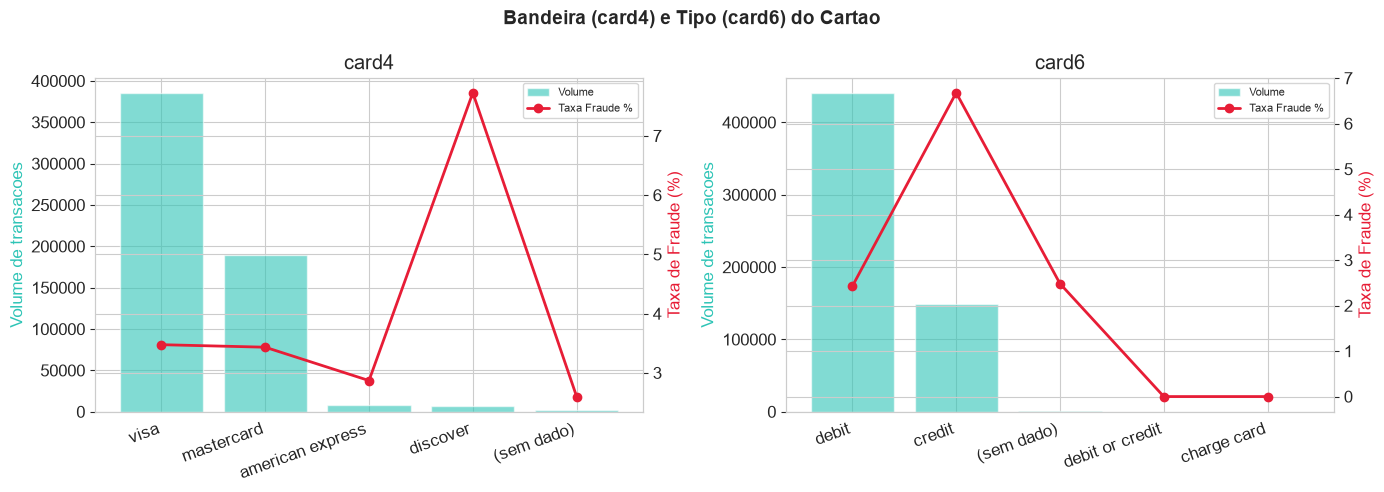

>> INSIGHT: Cartao de credito tem taxa de fraude de 6.7% vs 2.4% no debito.
   Quase 3x mais risco — card6 e uma feature discriminante importante.
   Discover tem taxa de 7.7%, mas representa apenas 1.1% do volume.


In [19]:
# CÉLULA 9 — Cartão: Bandeira (card4) e Tipo (card6)
# Cartão de crédito frauda quase 3× mais que débito — deve virar feature.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bandeira (card4) e Tipo (card6) do Cartao', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['card4', 'card6']):
    stats = df.groupby(col, dropna=False).agg(
        taxa=('isFraud', 'mean'),
        volume=('isFraud', 'count')
    ).reset_index().sort_values('volume', ascending=False)
    stats[col]    = stats[col].fillna('(sem dado)').astype(str)
    stats['taxa'] = stats['taxa'] * 100

    x   = range(len(stats))
    ax2 = ax.twinx()  # segundo eixo Y — permite sobrepor barras (volume) e linha (taxa)

    ax.bar(x, stats['volume'], color=PALETTE[0], alpha=0.6, label='Volume')
    ax2.plot(x, stats['taxa'], color=PALETTE[1], marker='o', linewidth=2, label='Taxa Fraude %')

    ax.set_xticks(x)
    ax.set_xticklabels(stats[col], rotation=20, ha='right')
    ax.set_ylabel('Volume de transacoes', color=PALETTE[0])
    ax2.set_ylabel('Taxa de Fraude (%)', color=PALETTE[1])
    ax.set_title(col)

    # combina as legendas dos dois eixos em uma só
    handles = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels_ = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax.legend(handles, labels_, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print('>> INSIGHT: Cartao de credito tem taxa de fraude de 6.7% vs 2.4% no debito.')
print('   Quase 3x mais risco — card6 e uma feature discriminante importante.')
print('   Discover tem taxa de 7.7%, mas representa apenas 1.1% do volume.')

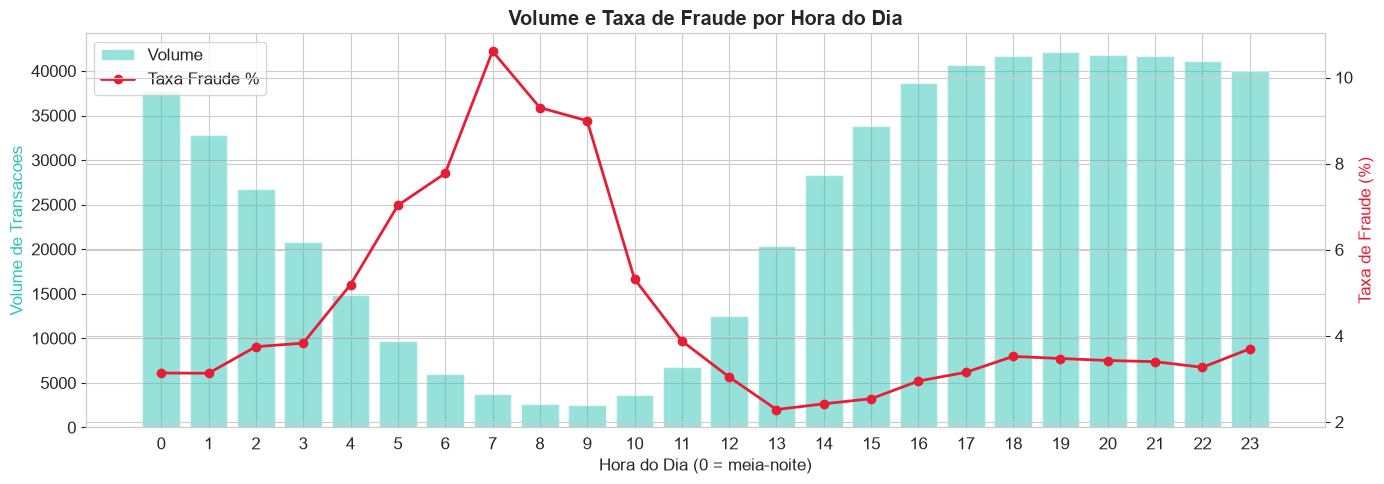

Hora de MAIOR fraude : 7h (10.6%)
Hora de MENOR fraude : 13h (2.3%)
>> INSIGHT: Pico de fraude na madrugada/manha cedo — menor vigilancia operacional.
   Diferenca de ~4.5x entre hora de pico e vale indica forte sinal preditivo.


In [20]:
# CÉLULA 10 — Padrão Temporal: Hora do Dia
# TransactionDT não é uma data real — é um contador em segundos desde uma
# data de referência. O padrão cíclico de hora (% 24) é real e preditivo.
df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24  # // divide sem decimal; % 24 = resto da divisão

hourly = df.groupby('HourOfDay')['isFraud'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax2 = ax.twinx()  # segundo eixo Y para sobrepor volume (barras) e taxa (linha)

ax.bar(hourly['HourOfDay'], hourly['count'], color=PALETTE[0], alpha=0.5, label='Volume')
ax2.plot(hourly['HourOfDay'], hourly['mean'] * 100,
         color=PALETTE[1], marker='o', linewidth=2, label='Taxa Fraude %')

ax.set_xlabel('Hora do Dia (0 = meia-noite)')
ax.set_ylabel('Volume de Transacoes', color=PALETTE[0])
ax2.set_ylabel('Taxa de Fraude (%)', color=PALETTE[1])
ax.set_title('Volume e Taxa de Fraude por Hora do Dia', fontweight='bold')
ax.set_xticks(range(0, 24))

handles = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels_ = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(handles, labels_, loc='upper left')
plt.tight_layout()
plt.show()

hora_max = hourly.set_index('HourOfDay')['mean'].idxmax()
hora_min = hourly.set_index('HourOfDay')['mean'].idxmin()
taxa_max = hourly[hourly['HourOfDay'] == hora_max]['mean'].values[0] * 100
taxa_min = hourly[hourly['HourOfDay'] == hora_min]['mean'].values[0] * 100
print(f'Hora de MAIOR fraude : {hora_max}h ({taxa_max:.1f}%)')
print(f'Hora de MENOR fraude : {hora_min}h ({taxa_min:.1f}%)')
print('>> INSIGHT: Pico de fraude na madrugada/manha cedo — menor vigilancia operacional.')
print('   Diferenca de ~4.5x entre hora de pico e vale indica forte sinal preditivo.')

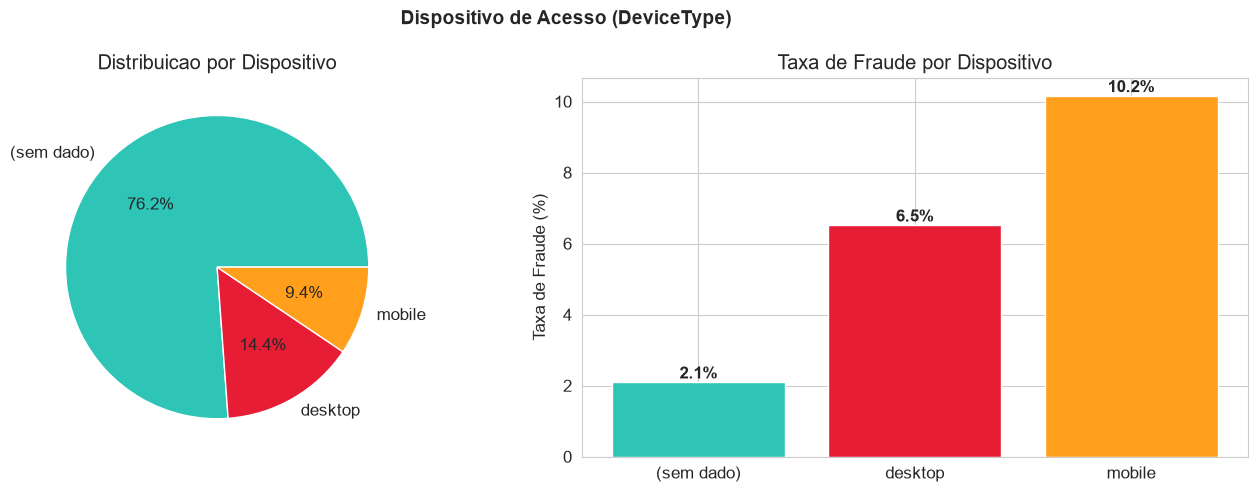

>> INSIGHT: Mobile tem 10.2% de fraude vs 6.5% desktop.
   Transacoes SEM dado de device tem apenas 2.1% — contra-intuitivo.
   Ausencia pode ser sinal positivo (transacao comum, sem alerta).


In [21]:
# CÉLULA 11 — Dispositivo (DeviceType)
# Ausência de device NÃO é neutra — transações sem dado têm taxa abaixo da
# média, sugerindo que o sistema coleta device quando detecta maior risco.
dev = df.groupby('DeviceType', dropna=False)['isFraud'].agg(['mean', 'count']).reset_index()
dev['DeviceType'] = dev['DeviceType'].fillna('(sem dado)').astype(str)
dev = dev.sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dispositivo de Acesso (DeviceType)', fontsize=14, fontweight='bold')

axes[0].pie(dev['count'], labels=dev['DeviceType'],
            colors=PALETTE[:len(dev)], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Distribuicao por Dispositivo')

barras = axes[1].bar(dev['DeviceType'], dev['mean'] * 100,
                     color=PALETTE[:len(dev)], edgecolor='white')
axes[1].set_ylabel('Taxa de Fraude (%)')
axes[1].set_title('Taxa de Fraude por Dispositivo')
for barra, val in zip(barras, dev['mean'] * 100):
    axes[1].text(barra.get_x() + barra.get_width()/2, val + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('>> INSIGHT: Mobile tem 10.2% de fraude vs 6.5% desktop.')
print('   Transacoes SEM dado de device tem apenas 2.1% — contra-intuitivo.')
print('   Ausencia pode ser sinal positivo (transacao comum, sem alerta).')

## BLOCO 5 — Correlações com Fraude

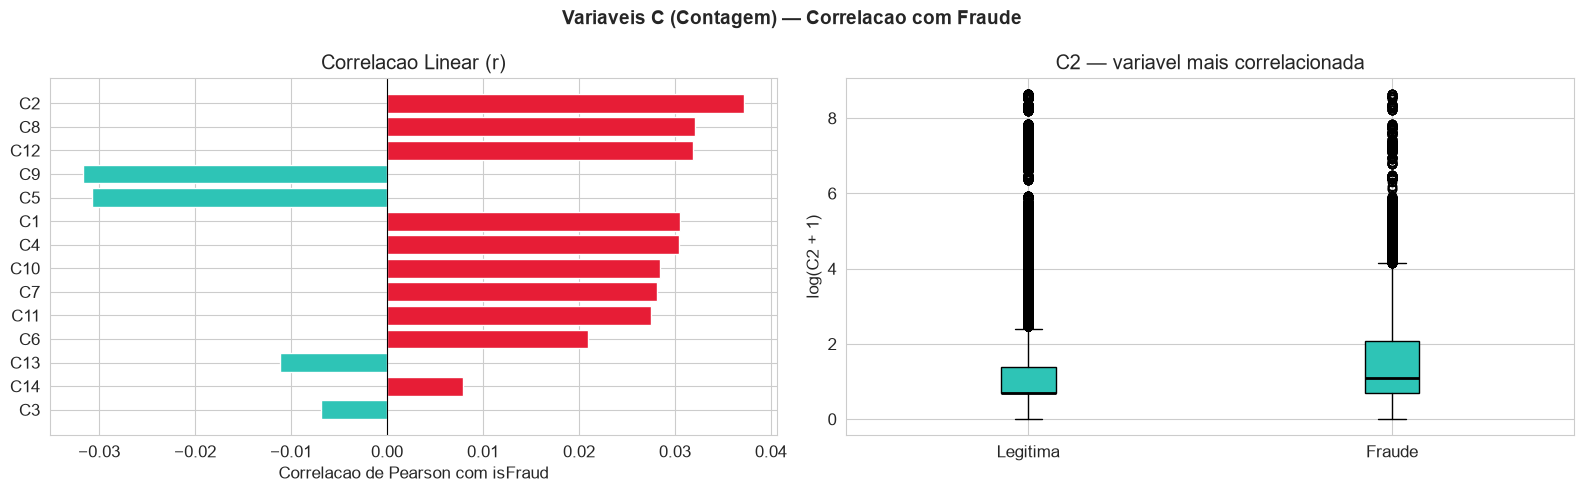

Variavel C mais correlacionada: C2 (r=0.037)
>> INSIGHT: Correlacoes C sao fracas (max |r|~0.04).
   Possuem relacoes nao-lineares — manter no modelo e deixar o algoritmo capturar.


In [24]:
# CÉLULA 12 — Variáveis C (Contagem)
# C = contagens de eventos (ex: quantas transações vieram do mesmo cartão).
# Correlação linear fraca não significa inútil — relação pode ser não-linear.
c_cols = [c for c in df.columns if c[0]=='C' and c[1:].isdigit()]

corr_c = df[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
corr_c = corr_c.sort_values(key=abs, ascending=False)  # key=abs: ordena pelo |valor|, ignora sinal

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Variaveis C (Contagem) — Correlacao com Fraude', fontsize=14, fontweight='bold')

bar_colors = [PALETTE[1] if v > 0 else PALETTE[0] for v in corr_c.values]
axes[0].barh(corr_c.index[::-1], corr_c.values[::-1], color=bar_colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlacao de Pearson com isFraud')
axes[0].set_title('Correlacao Linear (r)')

top_c = corr_c.index[0]
legit_c  = np.log1p(df[df['isFraud']==0][top_c].dropna())
fraude_c = np.log1p(df[df['isFraud']==1][top_c].dropna())
axes[1].boxplot([legit_c, fraude_c], tick_labels=['Legitima', 'Fraude'], patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0]),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel(f'log({top_c} + 1)')
axes[1].set_title(f'{top_c} — variavel mais correlacionada')

plt.tight_layout()
plt.show()

print(f'Variavel C mais correlacionada: {top_c} (r={corr_c[top_c]:.3f})')
print('>> INSIGHT: Correlacoes C sao fracas (max |r|~0.04).')
print('   Possuem relacoes nao-lineares — manter no modelo e deixar o algoritmo capturar.')

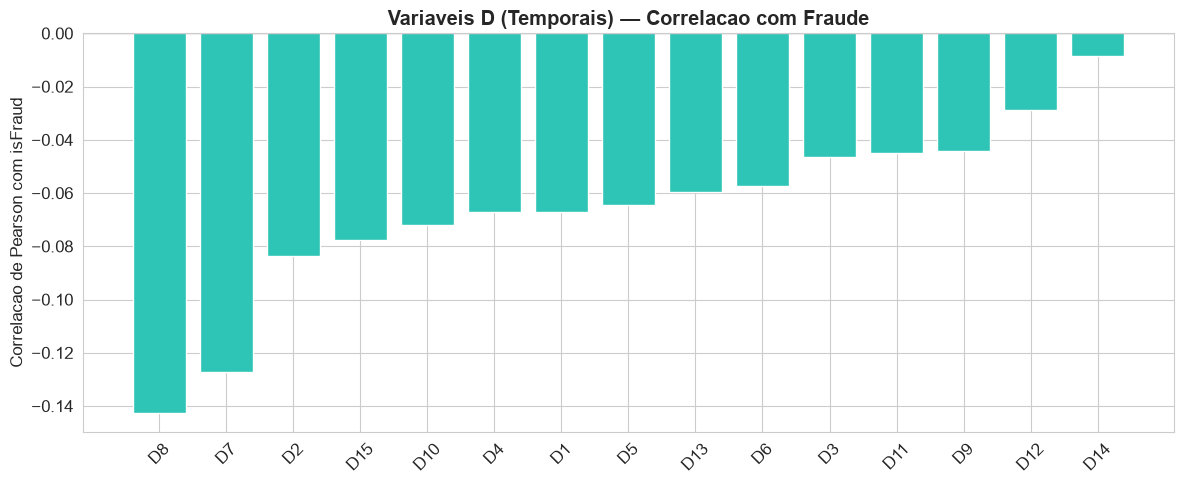

Variavel D mais correlacionada: D8 (r=-0.143)
>> INSIGHT: Sinal NEGATIVO em D8: quanto menor o valor (conta mais recente), maior o risco.
   Contas recentes sao alvos frequentes — variavel D e valiosa para o modelo.


In [25]:
# CÉLULA 13 — Variáveis D (Dias desde evento)
# D = 'dias desde' algum evento (ex: última transação, abertura da conta).
# Sinal negativo: conta mais antiga → menor risco.
d_cols = [c for c in df.columns if c[0]=='D' and c[1:].isdigit()]

corr_d = df[d_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').dropna()
corr_d = corr_d.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors_d = [PALETTE[1] if v > 0 else PALETTE[0] for v in corr_d.values]
ax.bar(corr_d.index, corr_d.values, color=bar_colors_d)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Correlacao de Pearson com isFraud')
ax.set_title('Variaveis D (Temporais) — Correlacao com Fraude', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Variavel D mais correlacionada: {corr_d.index[0]} (r={corr_d.iloc[0]:.3f})')
print(f'>> INSIGHT: Sinal NEGATIVO em {corr_d.index[0]}: quanto menor o valor (conta mais recente), maior o risco.')
print('   Contas recentes sao alvos frequentes — variavel D e valiosa para o modelo.')

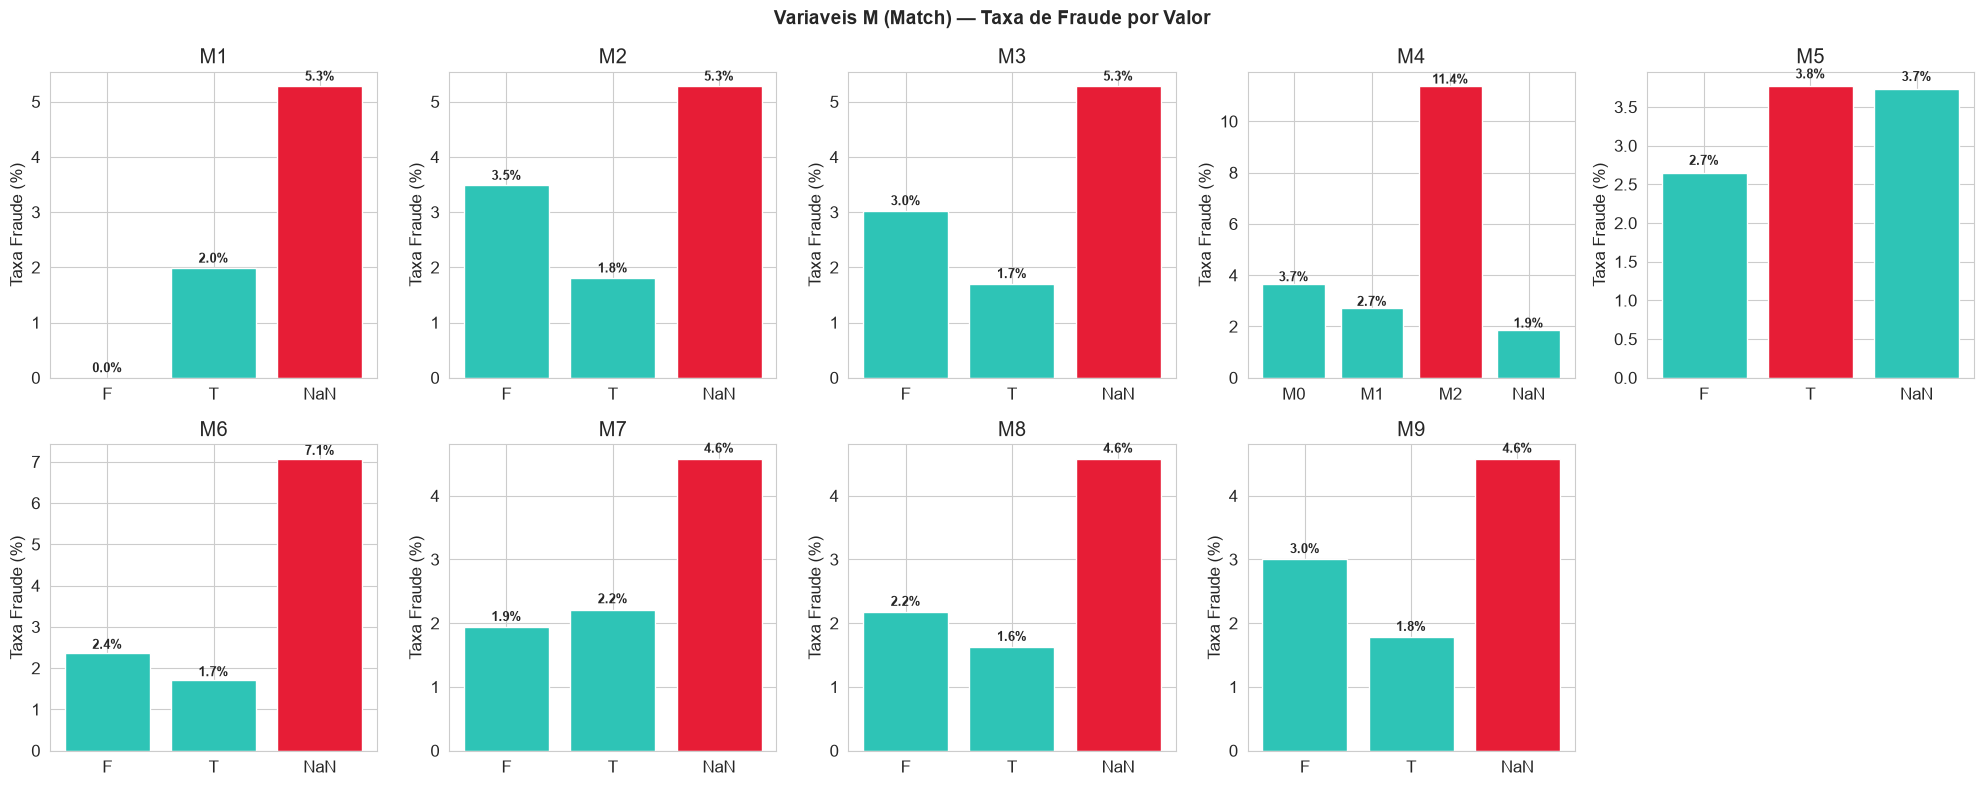

>> INSIGHT: M4=M2 tem 11.4% de fraude — valor mais alto entre as variaveis M.
   NaN em variaveis M: verificacao nao foi possivel — sinal de risco (4-7%).
   Estrategia: criar flag '_missing' para cada variavel M na ABT.


In [26]:
# CÉLULA 14 — Variáveis M (Match — flags de verificação)
# M indica se um campo foi validado (T=ok, F=falhou, NaN=não foi possível).
# Falha ou ausência de verificação costuma indicar risco maior.
m_cols = [c for c in df.columns if c[0]=='M' and c[1:].isdigit()]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Variaveis M (Match) — Taxa de Fraude por Valor', fontsize=14, fontweight='bold')
axes = axes.flatten()  # transforma o grid 2×5 em lista simples para iterar

for ax, col in zip(axes, m_cols):
    stats = df.groupby(col, dropna=False)['isFraud'].mean() * 100
    stats.index = stats.index.fillna('NaN').astype(str)
    bar_c = [PALETTE[1] if v == stats.max() else PALETTE[0] for v in stats.values]
    ax.bar(stats.index, stats.values, color=bar_c, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Taxa Fraude (%)')
    for i, v in enumerate(stats.values):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

for ax in axes[len(m_cols):]:
    ax.set_visible(False)  # esconde subplots extras (grid tem 10 espaços, M tem 9)

plt.tight_layout()
plt.show()

print('>> INSIGHT: M4=M2 tem 11.4% de fraude — valor mais alto entre as variaveis M.')
print('   NaN em variaveis M: verificacao nao foi possivel — sinal de risco (4-7%).')
print("   Estrategia: criar flag '_missing' para cada variavel M na ABT.")

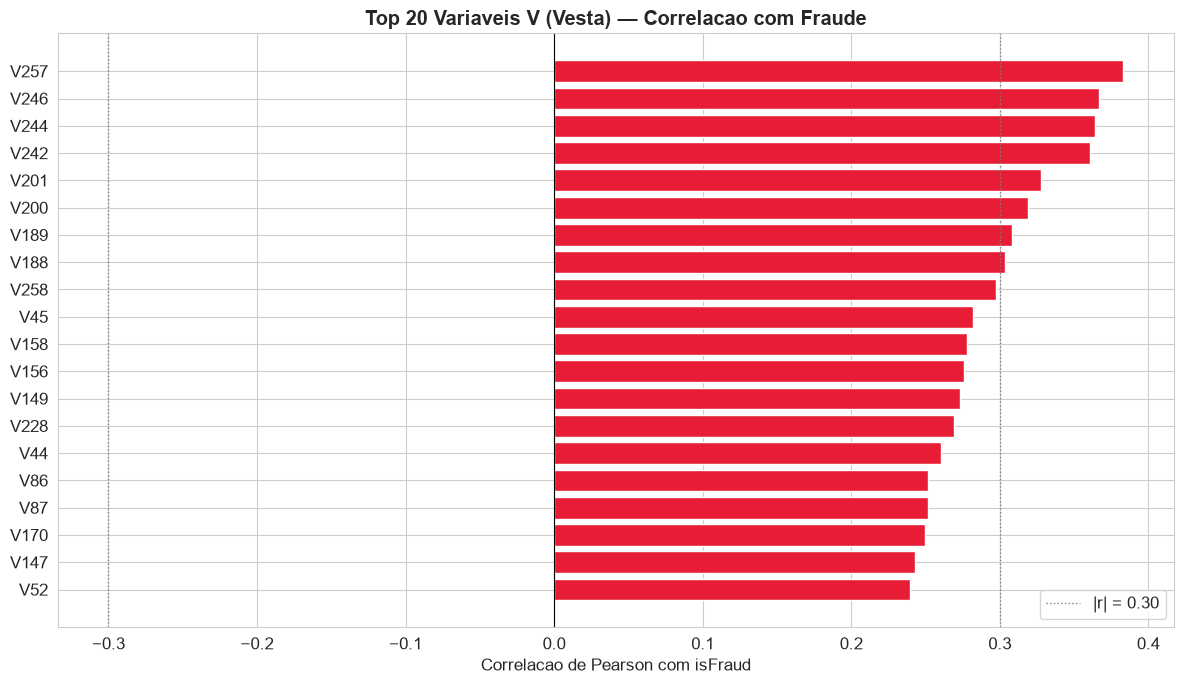

Top 10 variaveis V:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V com |r| > 0.30 : 8
V com |r| > 0.20 : 32
V com |r| > 0.10 : 113

>> INSIGHT: V257 tem r=0.383 — maior correlacao do dataset inteiro.
   8 variaveis Vesta com |r|>0.30, muito acima de qualquer variavel C ou D.
   Mesmo com alta missingness, as V sao candidatas prioritarias para o modelo.


In [27]:
# CÉLULA 15 — Variáveis V (Vesta) — Top Correlações
# V1–V339 são features proprietárias da Vesta: opacas, mas as mais preditivas.
# O modelo vai aprender a usá-las mesmo sem sabermos o que representam.
v_cols = [c for c in df.columns if c[0]=='V' and c[1:].isdigit()]

corr_v = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').dropna()
corr_v = corr_v.sort_values(key=abs, ascending=False)

top_v = corr_v.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors_v = [PALETTE[1] if v > 0 else PALETTE[0] for v in top_v.values]
ax.barh(top_v.index[::-1], top_v.values[::-1], color=bar_colors_v[::-1])
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.3,  color='gray', linestyle=':', linewidth=1, label='|r| = 0.30')
ax.axvline(-0.3, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Correlacao de Pearson com isFraud')
ax.set_title('Top 20 Variaveis V (Vesta) — Correlacao com Fraude', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 variaveis V:')
print(top_v.head(10).to_string())
print(f'V com |r| > 0.30 : {(corr_v.abs() > 0.30).sum()}')
print(f'V com |r| > 0.20 : {(corr_v.abs() > 0.20).sum()}')
print(f'V com |r| > 0.10 : {(corr_v.abs() > 0.10).sum()}')
print()
print(f'>> INSIGHT: {corr_v.index[0]} tem r={corr_v.iloc[0]:.3f} — maior correlacao do dataset inteiro.')
print('   8 variaveis Vesta com |r|>0.30, muito acima de qualquer variavel C ou D.')
print('   Mesmo com alta missingness, as V sao candidatas prioritarias para o modelo.')

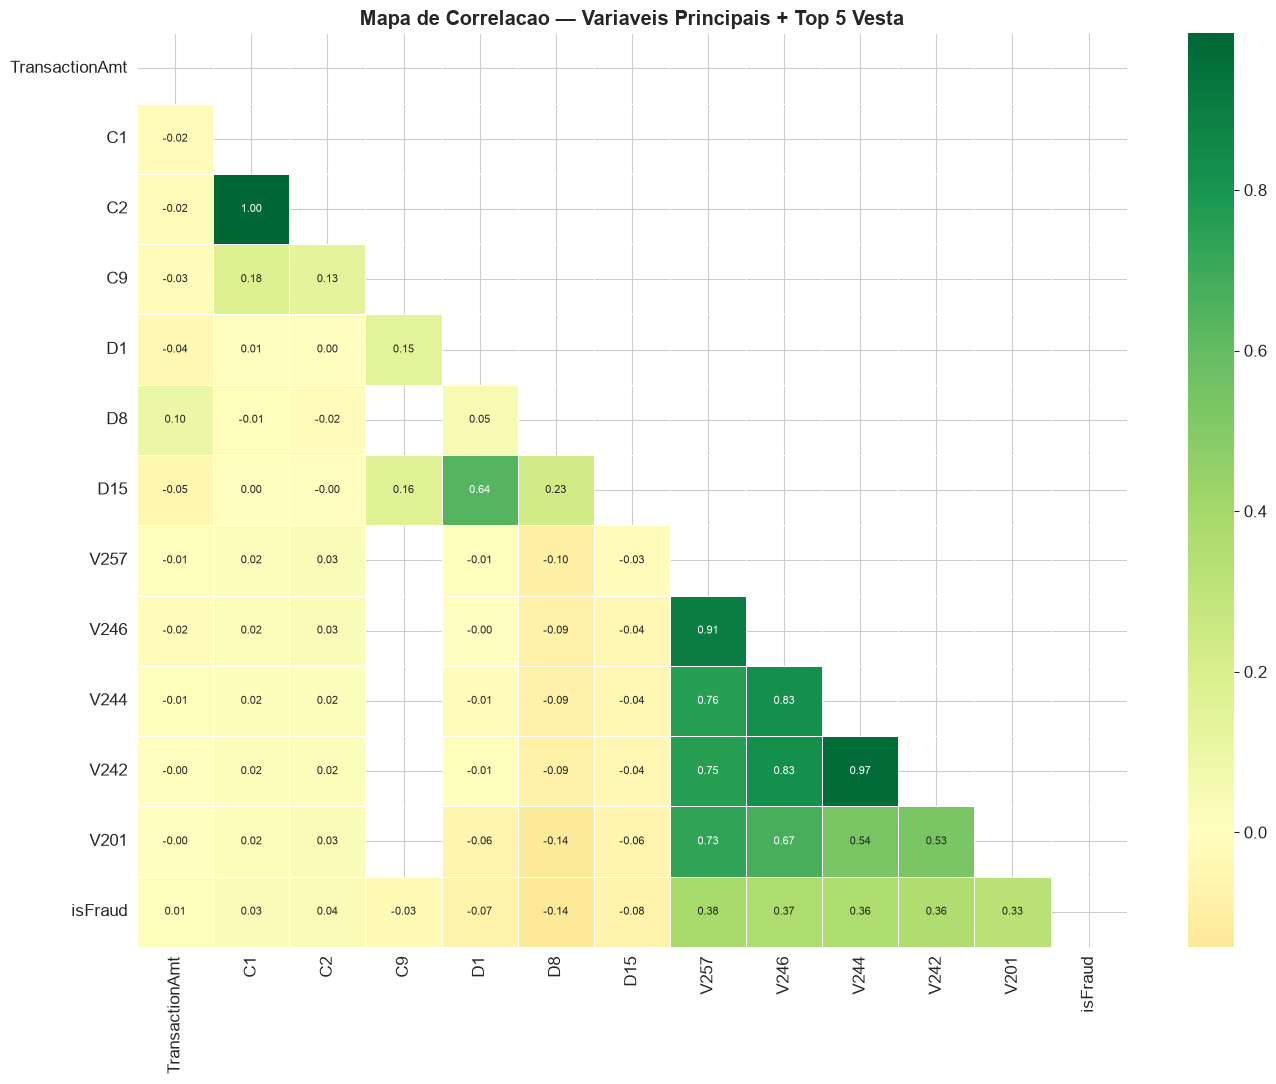

>> INSIGHT: As top Vesta tem correlacoes com isFraud muito superiores as C e D.
   Observe tambem a correlacao entre as proprias V — features muito correlacionadas
   entre si podem ser redundantes; tratar na Etapa 3 com selecao de features.


In [29]:
# CÉLULA 16 — Mapa de Correlação Geral (Heatmap)
# Inclui as top 5 Vesta para comparar com as variáveis C e D no mesmo mapa.
# Cores: verde = correlação positiva, vermelho = negativa.
top5_v   = corr_v.head(5).index.tolist()
num_cols = ['TransactionAmt', 'C1', 'C2', 'C9', 'D1', 'D8', 'D15'] + top5_v + ['isFraud']
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # oculta triângulo superior (redundante)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Mapa de Correlacao — Variaveis Principais + Top 5 Vesta', fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT: As top Vesta tem correlacoes com isFraud muito superiores as C e D.')
print('   Observe tambem a correlacao entre as proprias V — features muito correlacionadas')
print('   entre si podem ser redundantes; tratar na Etapa 3 com selecao de features.')

## Resumo — Síntese Executiva

In [30]:
# CÉLULA 17 — Resumo Executivo do EDA
# Pode ser rodada isoladamente após o merge (Célula 3) — recomputa tudo.

# --- recomputa variáveis necessárias ---
n_id   = df_ident['TransactionID'].nunique()
mp     = (df.isnull().mean() * 100).round(1)

vr     = [c for c in df.columns if c[0]=='V' and c[1:].isdigit()]
corr_vr = df[vr + ['isFraud']].corr()['isFraud'].drop('isFraud').dropna()
corr_vr = corr_vr.sort_values(key=abs, ascending=False)

cr     = [c for c in df.columns if c[0]=='C' and c[1:].isdigit()]
corr_cr = df[cr + ['isFraud']].corr()['isFraud'].drop('isFraud')
corr_cr = corr_cr.sort_values(key=abs, ascending=False)

is_fraud = df['isFraud']
vc       = is_fraud.value_counts()

# --- imprime resumo ---
print('=' * 65)
print('RESUMO EXECUTIVO — EDA | Banco FIA MBA Digital')
print('=' * 65)
print()
print('BLOCO 1 — ESTRUTURA')
print(f'  {len(df):,} transacoes | {df.shape[1]} variaveis apos merge')
print(f'  Com identidade: {n_id:,} ({n_id/len(df)*100:.1f}%) — {100-n_id/len(df)*100:.1f}% sem device/browser')
print()
print('BLOCO 2 — TARGET')
print(f'  Taxa de fraude: {is_fraud.mean()*100:.2f}% | Razao 1:{vc[0]//vc[1]:.0f}')
print('  Metrica correta: AUC-ROC (acuracia e enganosa com desbalanceamento)')
print("  Tratamento: class_weight='balanced' ou SMOTE na modelagem")
print()
print('BLOCO 3 — QUALIDADE')
print(f'  {(mp > 70).sum()} colunas com >70% nulos (candidatas a exclusao)')
print(f'  {((mp > 30) & (mp <= 70)).sum()} colunas com 30-70% nulos (avaliar caso a caso)')
print("  Estrategia: criar flag '_missing' antes de imputar")
print()
print('BLOCO 4 — VARIAVEIS-CHAVE')
print('  TransactionAmt: skewness 14 — aplicar log1p obrigatoriamente')
print('  ProductCD C (cashout): 11.7% de fraude — hotspot critico')
print('  card6 credito: 6.7% vs debito 2.4% — feature discriminante')
print('  HourOfDay: pico (~10%) vs vale (~2.3%) — 4.5x de diferenca')
print('  Mobile: 10.2% de fraude vs desktop 6.5%')
print()
print('BLOCO 5 — CORRELACOES')
print(f'  Melhor variavel linear: {corr_vr.index[0]} (r={corr_vr.iloc[0]:.3f}) — Vesta')
print(f'  Melhor variavel C: {corr_cr.index[0]} (r={corr_cr.iloc[0]:.3f}) — fraca individualmente')
print(f'  Variaveis Vesta com |r|>0.3: {(corr_vr.abs()>0.3).sum()} (de {len(vr)} totais)')
print()
print('PROXIMOS PASSOS — Etapa 3 (Preparacao / ABT):')
print('  1. Excluir colunas com >70% nulos (salvo excecoes preditivas)')
print("  2. Criar flags '_missing' para colunas com >30% nulos")
print('  3. Aplicar log1p em TransactionAmt')
print('  4. Codificar categoricas (LabelEncoder ou Target Encoding)')
print('  5. Priorizar top Vesta no feature selection')
print('  6. Tratar desbalanceamento na modelagem (nao na ABT)')

RESUMO EXECUTIVO — EDA | Banco FIA MBA Digital

BLOCO 1 — ESTRUTURA
  590,540 transacoes | 435 variaveis apos merge
  Com identidade: 144,233 (24.4%) — 75.6% sem device/browser

BLOCO 2 — TARGET
  Taxa de fraude: 3.50% | Razao 1:27
  Metrica correta: AUC-ROC (acuracia e enganosa com desbalanceamento)
  Tratamento: class_weight='balanced' ou SMOTE na modelagem

BLOCO 3 — QUALIDADE
  208 colunas com >70% nulos (candidatas a exclusao)
  24 colunas com 30-70% nulos (avaliar caso a caso)
  Estrategia: criar flag '_missing' antes de imputar

BLOCO 4 — VARIAVEIS-CHAVE
  TransactionAmt: skewness 14 — aplicar log1p obrigatoriamente
  ProductCD C (cashout): 11.7% de fraude — hotspot critico
  card6 credito: 6.7% vs debito 2.4% — feature discriminante
  HourOfDay: pico (~10%) vs vale (~2.3%) — 4.5x de diferenca
  Mobile: 10.2% de fraude vs desktop 6.5%

BLOCO 5 — CORRELACOES
  Melhor variavel linear: V257 (r=0.383) — Vesta
  Melhor variavel C: C2 (r=0.037) — fraca individualmente
  Variaveis Vest